# Signal_Tests — Building a *credible* trading signal with causal discovery

**Applied companion to** [`PCMCI_Intro.ipynb`](./PCMCI_Intro.ipynb) and
[`PCMCI_Finance_DeepDive.ipynb`](./PCMCI_Finance_DeepDive.ipynb).

The DeepDive built one signal end-to-end. This notebook is a **laboratory**: a panel
of **10 macro factors + ~120 single names** (real market data by default), wired so
that *every stage has its own knob block* (`🎛 KNOBS`). Change one thing, re-run
downstream, and watch the walk-forward Sharpe move. The goal is not a single number —
it is to learn which PCMCI and signal-design choices actually earn their keep on
*real* data, and which are noise.

### Two modes, and why both matter
- **Real data (default, `use_synthetic=False`).** Live `yfinance` prices. This is
  where you get *honest* numbers — and the honest number for a naive signal is
  usually **near zero or negative after costs**. That is the correct, sobering result:
  if lead-lag alpha were easy to harvest, it would already be arbitraged away.
- **Synthetic (`use_synthetic=True`).** A panel with *known* planted macro→stock
  edges. Use it as a **unit test of the machinery** — "does the code recover structure
  that is truly there?" — **not** as a performance estimate. It posts an absurd Sharpe
  precisely *because* the edges are clean and stable; real markets are neither.

### The credibility spine
A lead-lag pattern is cheap; a *credible* one survives adversarial checks (§9):
1. **Multiple-testing control** — you cannot eyeball `N²·τ_max` candidate links.
2. **Walk-forward, look-ahead-free backtest** — refit the graph on the *trailing*
   window only.
3. **A placebo** — permute time; a real signal must die (and a fake one won't).
4. **A causal-vs-correlation ablation** — does conditioning (PCMCI) beat a naive
   lagged-correlation signal? If not, the "causal" story is adding nothing.

> **The deliverable is the *gap* between the signal and its placebo/correlation
> baselines, not the raw Sharpe.** A disciplined "no alpha here" is worth more than a
> fantasy Sharpe.

> **Runtime.** §2–§7 (one graph fit) are near-instant. §8–§9 refit dozens of times on
> ~120 names → **several minutes** at defaults. For a fast first pass set `max_refits=6`
> in §0. The default pulls live data (needs network); flip `use_synthetic=True` to run
> offline.

---
## 1. What the literature actually says <a name="lit"></a>

A grounding pass so our design choices are defensible, not arbitrary.

**Causal discovery *can* move portfolio metrics — but algorithm and data size
matter.** Across PCMCI, VarLiNGAM, DYNOTEARS and Granger variants, *adding a
causal-discovery stage generally improved returns, with the benefit growing as the
dataset grew*; VarLiNGAM scaled best (Ong & Herremans, *Trading with Time Series
Causal Discovery*, 2024). Takeaway: **universe size is itself a knob.**

**Structural correctness may be a weaker requirement than it seems.** For an efficient
frontier you may not need the *true* graph — **directional validity + approximate
calibration can suffice** even under misspecification (*Is Causality Necessary for
Efficient Portfolios?*, 2025). Reading: chase **sign-stable** edges, not graph
perfection (→ the `edge_weight="sign"` knob).

**Nonstationarity quietly breaks finance applications.** CD-NOTS shows a graph fit on
2000–2007 is simply *wrong* for 2016–2022 (*Causal Discovery in Financial Markets*,
2023). We honor this with **trailing-window refits** (§8) and a **cross-window
stability check** (§9).

**Frequency and CI-test choice are load-bearing.** The same work recommends `ParCorr`
in **low-data regimes (< ~200 obs)** — daily equity windows are *always* thin. And
**daily returns are almost all microstructure noise**: genuine cross-asset lead-lag is
far cleaner at **weekly** frequency (our default). This is *the* lever that turns a
zero-edge daily run into a signal you can actually study.

**Why any of this beats a correlation matrix** (formal case, DeepDive §1.1):
Reichenbach's common-cause principle (a correlation is consistent with X→Y, Y→X, *or*
a hidden driver); Pearl's Causal Hierarchy Theorem (you provably cannot get the
interventional "if I trade on this" answer from correlation alone); Granger–Newbold
spurious regression (nonstationary series manufacture significant lead-lag
correlations from noise). PCMCI's MCI step conditions those away — a surviving edge is
a *candidate* for invariant, transportable structure (Peters, Bühlmann & Meinshausen,
*Invariant Prediction*, JRSS-B 2016).

*Full citations in §11.*

---
## 0. Experiment harness & global knobs <a name="harness"></a>

One import cell + one master-config cell. Everything downstream reads from `CFG`, so a
single edit re-parameterizes the whole study.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings, time
from dataclasses import dataclass, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
# Optional CI tests imported lazily in §4 so a missing optional dep never blocks the run.

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": .3})
print("tigramite / pandas / numpy ready.")

tigramite / pandas / numpy ready.


In [2]:
# ── 🎛 MASTER CONFIG — the single source of truth ────────────────────────────
# window / rebal_every / tau_max are in *periods* (= weeks if frequency="weekly",
# else days). Defaults are tuned for WEEKLY. For daily, use ~ window=250,
# rebal_every=21, tau_max=5 (see the comments).
@dataclass
class Config:
    # data
    use_synthetic: bool = False         # False = REAL yfinance (realistic). True = planted-truth unit test.
    frequency: str = "weekly"           # "weekly" (less noise, real lead-lag) | "daily" (mostly noise)
    start: str = "2016-01-01"
    end:   str = "2024-01-01"
    n_synth_stocks: int = 120           # synthetic universe size (real path uses the ticker list)
    return_type: str = "log"            # "log" | "simple"
    # preprocessing (§3)
    standardize: bool = True
    winsor_q: float = 0.0               # clip returns beyond this quantile each side (0 = off)
    vol_normalize: bool = False
    # PCMCI (§4)
    tau_min: int = 1
    tau_max: int = 4                    # periods of memory (~4 weeks). Daily: ~5.
    pc_alpha: float = 0.05
    alpha: float = 0.05                # edge-acceptance level
    ci_test: str = "parcorr"           # "parcorr" | "robust_parcorr" | "gpdc"(slow)
    fdr_scope: str = "per_target"      # "per_target" (each stock its own test set) | "global" (strict) | "none"(exploratory)
    graph_shape: str = "macro_drives"  # "macro_drives" | "plus_xstock" | "full"  (see §4)
    # signal (§6)
    edge_weight: str = "mci"           # "mci" | "sign" | "mci_over_p"
    aggregate: str = "sum"             # "sum" | "mean"
    # portfolio (§7)
    strategy_style: str = "long_tilt"  # "long_tilt" (own the market, tilt by signal) | "long_short" (dollar-neutral)
    tilt_strength: float = 2.0         # long_tilt: how hard the causal signal tilts the long book
    quantile: float = 0.2              # long_short: trade top/bottom 20% by score
    # backtest (§8)
    window: int = 150                  # trailing periods to refit the graph (~150 wk ≈ 3y). Daily: ~250.
    rebal_every: int = 13              # refit cadence in periods (~quarterly). Daily: ~21.
    cost_bps: float = 1.0              # per-side cost on turnover, basis points
    max_refits: int = 0                # 0 = full history; else cap (fast smoke runs)

    @property
    def ppy(self):                     # periods per year, for annualization
        return 52 if self.frequency == "weekly" else 252

CFG = Config()
print(CFG)

Config(use_synthetic=False, frequency='weekly', start='2016-01-01', end='2024-01-01', n_synth_stocks=120, return_type='log', standardize=True, winsor_q=0.0, vol_normalize=False, tau_min=1, tau_max=4, pc_alpha=0.05, alpha=0.05, ci_test='parcorr', fdr_scope='per_target', graph_shape='macro_drives', edge_weight='mci', aggregate='sum', strategy_style='long_tilt', tilt_strength=2.0, quantile=0.2, window=150, rebal_every=13, cost_bps=1.0, max_refits=0)


---
## 2. Universe & data <a name="data"></a>

**10 macro factors, then ~120 single names.** Column *order* (macro-first) defines
every index downstream. `build_panel(CFG)` returns `(rets, var_names, n_macro, truth)`
where `rets` is a `DataFrame` of periodic returns.

- **Live** (default): liquid macro ETFs + a curated large-cap basket via `yfinance`,
  resampled to the chosen `frequency`. `truth=None` (no ground truth to recover).
- **Synthetic**: macros are AR(1); each stock is driven by a random (macro, lag) pair
  + own momentum + noise, with a *known* `truth` so §5/§9 can measure recovery.

🎛 **Knobs to try:** `use_synthetic`, `frequency`, `start/end`, `n_synth_stocks`, and
the ticker lists below (swap sectors, grow to 150 names).

In [3]:
# 10 macro factors (liquid ETFs + VIX) and a curated ~120-name large/mid-cap basket.
MACRO_TICKERS = ["SPY", "IWM", "TLT", "IEF", "LQD", "HYG", "GLD", "USO", "UUP", "^VIX"]
MACRO_NAMES   = ["mkt", "smallcap", "bond20y", "bond10y", "ig_credit",
                 "hy_credit", "gold", "oil", "usd", "vix"]

STOCK_TICKERS = [
    # tech / comm
    "AAPL","MSFT","NVDA","GOOGL","META","AMZN","AVGO","ORCL","CRM","ADBE","AMD","INTC",
    "CSCO","QCOM","TXN","IBM","NOW","INTU","AMAT","MU","ADI","LRCX","KLAC","PANW",
    "NFLX","DIS","CMCSA","T","VZ","TMUS",
    # financials
    "JPM","BAC","WFC","GS","MS","C","BLK","SCHW","AXP","SPGI","CB","PGR","USB","PNC","BK",
    # health care
    "UNH","JNJ","LLY","PFE","MRK","ABBV","TMO","ABT","DHR","BMY","AMGN","GILD","CVS","MDT","ISRG","VRTX",
    # consumer
    "WMT","HD","COST","PG","KO","PEP","MCD","NKE","SBUX","LOW","TGT","BKNG","CL","MDLZ","EL","TJX",
    # industrials / materials
    "CAT","BA","GE","HON","UNP","UPS","RTX","LMT","DE","MMM","EMR","ETN","NSC","FDX","LIN","APD","SHW","FCX","NEM",
    # energy / utilities
    "XOM","CVX","COP","SLB","EOG","PSX","MPC","OXY","NEE","DUK","SO","D",
    # travel / misc
    "DAL","UAL","LUV","MAR","GM","F","V","MA","PYPL","ADP",
]
print(f"{len(MACRO_TICKERS)} macros, {len(STOCK_TICKERS)} stocks defined "
      f"(trim/extend STOCK_TICKERS to hit your 100–150 target).")

10 macros, 118 stocks defined (trim/extend STOCK_TICKERS to hit your 100–150 target).


In [4]:
def _to_returns(px, cfg):
    """Prices -> periodic returns at the chosen frequency."""
    if cfg.frequency == "weekly":
        px = px.resample("W-FRI").last().dropna(how="any")
    return (np.log(px).diff() if cfg.return_type == "log" else px.pct_change()).dropna()


def _make_synthetic(cfg, n_macro=10):
    """Planted-truth panel. truth[s] = (macro_idx, lag, coef). NOTE: clean & stable by
    design -> inflated backtest; use ONLY to check the machinery recovers structure."""
    rng = np.random.default_rng(7)
    n_stock = cfg.n_synth_stocks
    n = n_macro + n_stock
    dates = (pd.bdate_range(cfg.start, cfg.end) if cfg.frequency == "daily"
             else pd.date_range(cfg.start, cfg.end, freq="W-FRI"))
    T = len(dates)
    x = np.zeros((T, n)); x[0] = rng.standard_normal(n) * 0.01
    truth = {s: (int(rng.integers(0, n_macro)),
                 int(rng.integers(cfg.tau_min, cfg.tau_max + 1)),
                 float(rng.uniform(0.15, 0.45) * rng.choice([-1, 1])))
             for s in range(n_macro, n)}
    for t in range(1, T):
        for i in range(n_macro):
            x[t, i] = 0.25 * x[t-1, i] + 0.01 * rng.standard_normal()
        for s in range(n_macro, n):
            m, lag, c = truth[s]
            x[t, s] = (c * x[t-lag, m] if t-lag >= 0 else 0.0) + 0.10 * x[t-1, s] + 0.012 * rng.standard_normal()
    names = MACRO_NAMES[:n_macro] + [f"stk{k:03d}" for k in range(n_stock)]
    return pd.DataFrame(x, index=dates, columns=names), names, n_macro, truth


def _make_live(cfg, n_macro=10):
    """Pull adjusted closes, align calendar, resample, convert to returns."""
    import yfinance as yf
    tickers = MACRO_TICKERS + STOCK_TICKERS
    raw = yf.download(tickers, start=cfg.start, end=cfg.end, auto_adjust=True, progress=False)["Close"]
    px = raw[tickers].dropna(how="all", axis=1).dropna(how="any")   # drop dead tickers, then align calendar
    rets = _to_returns(px, cfg)
    names = MACRO_NAMES + [c.lower().replace("^", "") for c in px.columns[n_macro:]]
    rets.columns = names
    return rets, names, n_macro, None


def build_panel(cfg):
    rets, names, n_macro, truth = (_make_synthetic(cfg) if cfg.use_synthetic else _make_live(cfg))
    print(f"Panel: {rets.shape[0]} {cfg.frequency} bars x {rets.shape[1]} series "
          f"({n_macro} macro + {rets.shape[1]-n_macro} stock)  "
          f"[{rets.index.min().date()} -> {rets.index.max().date()}]  "
          f"{'SYNTHETIC (unit test)' if cfg.use_synthetic else 'LIVE'}")
    return rets, names, n_macro, truth


RETS, VAR_NAMES, N_MACRO, TRUTH = build_panel(CFG)
N_VARS   = len(VAR_NAMES)
STOCK_IDX = list(range(N_MACRO, N_VARS))
RETS.iloc[:3, :6]

Panel: 416 weekly bars x 128 series (10 macro + 118 stock)  [2016-01-15 -> 2023-12-29]  LIVE


,mkt,smallcap,bond20y,bond10y,ig_credit,hy_credit
Date,,,,,,
2016-01-15,-0.021647,-0.036578,0.019189,0.007809,-0.004371,-0.020454
2016-01-22,0.014326,0.012408,-0.003266,-0.001112,-0.005270,0.011740
2016-01-29,0.016657,0.015563,0.015516,0.011430,0.005358,0.005818


---
## 3. Preprocessing & frequency — mapping choices to assumptions <a name="prep"></a>

PCMCI assumes weak stationarity and a correctly specified CI test. These choices are
knobs because the "right" answer is empirical.

| Knob | What it does | Why it matters |
|---|---|---|
| **`frequency`** | daily vs **weekly** returns | *The* signal-to-noise lever. Daily returns are ~all microstructure noise — on real data a daily run often finds **zero** robust edges after FDR. Weekly aggregation surfaces genuine cross-asset lead-lag. |
| `standardize` | z-score each series **on the fit window** | comparable scales for ParCorr (done *inside* the window → no look-ahead) |
| `winsor_q` | clip fat-tail return outliers | protects the linear-Gaussian CI test |
| `vol_normalize` | divide by trailing realized vol | stationarity of variance |

`preprocess(window_array, cfg)` runs on **each trailing window**, so nothing leaks the
future.

🎛 **Knobs to try:** switch `frequency` to `"daily"` and watch edges collapse; set
`winsor_q=0.01`; toggle `standardize`/`vol_normalize`.

In [5]:
def preprocess(arr, cfg):
    """arr: (T_window, N) raw returns -> transformed copy. Stats computed within the
    window only (no look-ahead)."""
    x = np.asarray(arr, dtype=float).copy()
    if cfg.vol_normalize:
        vol = np.std(x, axis=0, keepdims=True); vol[vol == 0] = 1.0
        x = x / vol
    if cfg.winsor_q and cfg.winsor_q > 0:
        lo = np.quantile(x, cfg.winsor_q, axis=0, keepdims=True)
        hi = np.quantile(x, 1 - cfg.winsor_q, axis=0, keepdims=True)
        x = np.clip(x, lo, hi)
    if cfg.standardize:
        mu = x.mean(axis=0, keepdims=True); sd = x.std(axis=0, keepdims=True); sd[sd == 0] = 1.0
        x = (x - mu) / sd
    return x

# stationarity gut-check on the tail window (ADF: low p => stationary)
from statsmodels.tsa.stattools import adfuller
_win = preprocess(RETS.values[-CFG.window:], CFG)
_pv = [adfuller(_win[:, j], maxlag=3, autolag=None)[1] for j in range(min(6, N_VARS))]
print("ADF p-values (first 6 series, want << 0.05):",
      ", ".join(f"{VAR_NAMES[j]}={p:.3f}" for j, p in enumerate(_pv)))

ADF p-values (first 6 series, want << 0.05): mkt=0.000, smallcap=0.000, bond20y=0.000, bond10y=0.000, ig_credit=0.000, hy_credit=0.000


---
## 4. PCMCI configuration — the heart of the experiment <a name="pcmci"></a>

Three design levers do most of the work.

**(a) `graph_shape` — the candidate-parent policy (`link_assumptions`).** Testing all
`N²·τ_max` links on 130 series is wasteful *and* statistically reckless. We tell PCMCI
which links may even exist:
- `"macro_drives"` — a stock's only candidate parents are the **10 macros** (+ own
  lag). Encodes *"a single name doesn't move oil, but oil moves airlines,"* shrinks
  each stock's search from 130 candidates to ~11 → fast, far fewer tests to correct.
- `"plus_xstock"` — also allow **stock→stock** cross edges (richer, slower, more false
  positives).
- `"full"` — everyone parents everyone (cautionary baseline for runtime/blowup).

**(b) `fdr_scope` — how you pay for multiple testing.** This is *why* daily runs come
back empty:
- `"global"` — one BH-FDR across **all** `~5,000` candidate links. Correct but brutal;
  on real data it often accepts **zero** edges.
- `"per_target"` (default) — treat each stock as its **own** discovery problem and
  BH-correct only across *its* ~40 candidate links. Far more powerful and defensible
  (each stock is a separate hypothesis family).
- `"none"` — raw `alpha`, no correction. **Exploratory only** — this is the
  false-positive trap the DeepDive warns about (hundreds of "edges" that are noise).

**(c) `ci_test`** — `ParCorr` (linear partial correlation) is right for thin return
windows. `robust_parcorr` down-weights outliers; `gpdc` is nonlinear but slow and
variance-hungry (expect it to *cost* Sharpe unless you have a specific nonlinearity).

🎛 **Knobs to try:** `graph_shape`, `fdr_scope` (watch edge count swing), `tau_max`,
`pc_alpha`, `ci_test`.

In [6]:
def allowed_sources(cfg, n_macro, n_vars, j):
    """Candidate parents of target j under the graph_shape policy."""
    if cfg.graph_shape == "full" or (cfg.graph_shape == "plus_xstock" and j >= n_macro):
        return list(range(n_vars))
    if j < n_macro:                       # macros parented only by macros
        return list(range(n_macro))
    return list(range(n_macro)) + [j]     # macro_drives: macros + own lag


def build_link_assumptions(cfg, n_macro, n_vars):
    la = {}
    for j in range(n_vars):
        d = {}
        for i in allowed_sources(cfg, n_macro, n_vars, j):
            for tau in range(cfg.tau_min, cfg.tau_max + 1):
                d[(i, -tau)] = '-?>'     # a directed link whose existence PCMCI must test
        la[j] = d
    return la


def make_ci_test(cfg):
    if cfg.ci_test == "parcorr":        return ParCorr(significance="analytic")
    if cfg.ci_test == "robust_parcorr":
        from tigramite.independence_tests.robust_parcorr import RobustParCorr
        return RobustParCorr(significance="analytic")
    if cfg.ci_test == "gpdc":
        from tigramite.independence_tests.gpdc import GPDC
        return GPDC(significance="analytic")
    raise ValueError(f"unknown ci_test {cfg.ci_test!r}")


def _bh_accept(pvals, alpha):
    """Benjamini-Hochberg -> boolean accept mask (controls FDR at `alpha`)."""
    pvals = np.asarray(pvals, dtype=float); m = len(pvals)
    if m == 0:
        return np.zeros(0, bool)
    order = np.argsort(pvals)
    passed = pvals[order] <= alpha * (np.arange(1, m + 1) / m)
    k = np.where(passed)[0]
    acc = np.zeros(m, bool)
    if len(k):
        acc[order[:k.max() + 1]] = True
    return acc


def fit_pcmci(window_array, cfg, n_macro):
    """Fit PCMCI on one preprocessed window.
    Returns (val_matrix, p_matrix, accepted_bool_matrix) — `accepted` already encodes
    the FDR policy, so downstream code just reads the boolean."""
    x = preprocess(window_array, cfg)
    n_vars = x.shape[1]
    df = pp.DataFrame(x, var_names=[str(k) for k in range(n_vars)])
    pcmci = PCMCI(dataframe=df, cond_ind_test=make_ci_test(cfg), verbosity=0)
    res = pcmci.run_pcmci(tau_min=cfg.tau_min, tau_max=cfg.tau_max,
                          pc_alpha=cfg.pc_alpha,
                          link_assumptions=build_link_assumptions(cfg, n_macro, n_vars))
    p, val = res["p_matrix"], res["val_matrix"]
    accepted = np.zeros_like(p, dtype=bool)
    if cfg.fdr_scope == "global":
        q = pcmci.get_corrected_pvalues(p_matrix=p, fdr_method="fdr_bh",
                                        tau_min=cfg.tau_min, tau_max=cfg.tau_max)
        accepted = q < cfg.alpha
    else:
        for j in range(n_vars):
            links = [(i, tau) for i in allowed_sources(cfg, n_macro, n_vars, j)
                     for tau in range(cfg.tau_min, cfg.tau_max + 1) if i != j]
            pv = [p[i, j, tau] for i, tau in links]
            acc = (_bh_accept(pv, cfg.alpha) if cfg.fdr_scope == "per_target"
                   else np.asarray(pv) < cfg.alpha)              # "none"
            for (i, tau), a in zip(links, acc):
                accepted[i, j, tau] = a
    return val, p, accepted


t0 = time.time()
VAL, PMAT, ACC = fit_pcmci(RETS.values[-CFG.window:], CFG, N_MACRO)
print(f"Fit '{CFG.graph_shape}' graph (fdr={CFG.fdr_scope}) on {CFG.window}-bar window "
      f"in {time.time()-t0:.1f}s | {int(ACC.sum())} links accepted")

Fit 'macro_drives' graph (fdr=per_target) on 150-bar window in 3.8s | 32 links accepted


---
## 5. Extract & inspect the causal graph <a name="edges"></a>

Turn the matrices into an edge list and *interrogate* it before trusting it: signal
sparsity, which macros are the busiest drivers, and — on synthetic data — recovery of
planted truth.

> On **real** data expect **few** edges (single digits to a few dozen). That sparsity
> is honest: most candidate lead-lag links are noise, and FDR is doing its job. A
> signal from a handful of stable edges beats one from many spurious ones. If you see
> *hundreds* of edges, you almost certainly set `fdr_scope="none"`.

In [7]:
def extract_edges(val, p, accepted, n_macro, n_vars):
    """-> list of {src,tgt,lag,mci,p} for accepted, cross-variable edges."""
    edges = []
    for i, j, tau in np.argwhere(accepted):              # accepted already encodes the FDR policy
        if i != j:
            edges.append(dict(src=int(i), tgt=int(j), lag=int(tau),
                              mci=float(val[i, j, tau]), p=float(p[i, j, tau])))
    return edges


EDGES = extract_edges(VAL, PMAT, ACC, N_MACRO, N_VARS)
stocks_with_parent = {e["tgt"] for e in EDGES if e["tgt"] in STOCK_IDX}
print(f"{len(EDGES)} accepted edges | {len(stocks_with_parent)}/{len(STOCK_IDX)} "
      f"stocks have >=1 causal parent (signal sparsity)\n")

from collections import Counter
drv = Counter(VAR_NAMES[e["src"]] for e in EDGES if e["src"] < N_MACRO and e["tgt"] in STOCK_IDX)
print("Top macro drivers (edge count):",
      ", ".join(f"{k}:{v}" for k, v in drv.most_common(8)) or "(none)")

for e in sorted(EDGES, key=lambda z: -abs(z["mci"]))[:10]:
    kind = "CROSS" if e["src"] < N_MACRO else "xstk "
    print(f"  [{kind}] {VAR_NAMES[e['src']]}(t-{e['lag']}) "
          f"--MCI={e['mci']:+.3f} (p={e['p']:.4f})--> {VAR_NAMES[e['tgt']]}(t)")

if TRUTH is not None:
    got = {(e["src"], e["tgt"], e["lag"]) for e in EDGES}
    hit = sum((m, s, lag) in got for s, (m, lag, c) in TRUTH.items())
    print(f"\nRecovery vs planted truth: {hit}/{len(TRUTH)} true macro->stock edges found.")

32 accepted edges | 17/118 stocks have >=1 causal parent (signal sparsity)

Top macro drivers (edge count): oil:8, bond10y:6, bond20y:5, usd:4, ig_credit:2
  [CROSS] usd(t-1) --MCI=-0.392 (p=0.0000)--> cl(t)
  [CROSS] oil(t-3) --MCI=+0.321 (p=0.0001)--> unp(t)
  [CROSS] bond10y(t-2) --MCI=+0.305 (p=0.0002)--> adi(t)
  [CROSS] oil(t-1) --MCI=-0.304 (p=0.0002)--> panw(t)
  [CROSS] ig_credit(t-2) --MCI=+0.304 (p=0.0003)--> isrg(t)
  [CROSS] bond20y(t-2) --MCI=+0.303 (p=0.0003)--> googl(t)
  [CROSS] bond20y(t-2) --MCI=+0.301 (p=0.0003)--> amzn(t)
  [CROSS] bond20y(t-2) --MCI=+0.300 (p=0.0003)--> isrg(t)
  [CROSS] oil(t-4) --MCI=-0.299 (p=0.0003)--> pypl(t)
  [CROSS] usd(t-1) --MCI=-0.297 (p=0.0003)--> duk(t)


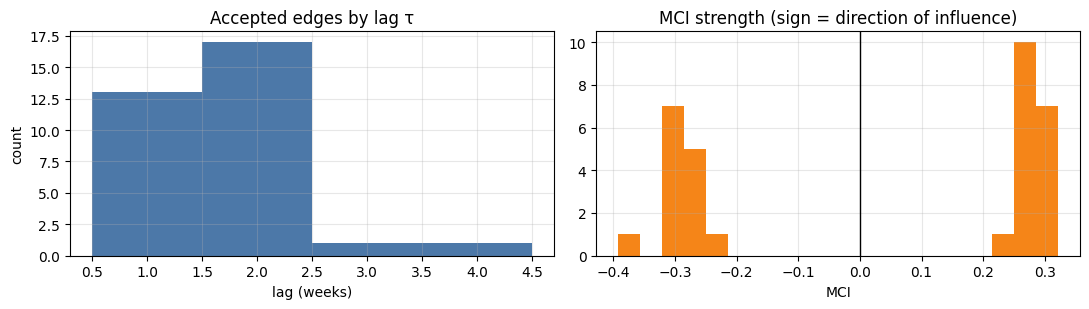

In [8]:
# Diagnostics: lag distribution + MCI-strength histogram of accepted edges.
if EDGES:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    ax[0].hist([e["lag"] for e in EDGES],
               bins=np.arange(CFG.tau_min, CFG.tau_max + 2) - 0.5, color="#4C78A8")
    ax[0].set(title="Accepted edges by lag τ", xlabel=f"lag ({CFG.frequency[:-2]}s)", ylabel="count")
    ax[1].hist([e["mci"] for e in EDGES], bins=20, color="#F58518"); ax[1].axvline(0, color="k", lw=1)
    ax[1].set(title="MCI strength (sign = direction of influence)", xlabel="MCI")
    plt.tight_layout(); plt.show()
else:
    print("No edges to plot — try frequency='weekly', fdr_scope='per_target', or a looser alpha.")

---
## 6. From graph to signal — the causal-momentum score <a name="signal"></a>

Core hypothesis: *if a stock's causal parents just moved, the stock is likely to move
next, in the direction and strength each edge implies.* For stock $s$ with edge
$i \xrightarrow{\tau,\,\text{MCI}} s$:

$$\text{score}_s(t) \;=\; \underset{(i,\tau,\text{MCI})\in\mathcal P(s)}{\text{agg}}\; w(\text{MCI},p)\cdot r_i(t-\tau)$$

Every $r_i(t-\tau)$ with $\tau\ge 1$ is **known at the start of period $t$** → the
signal is look-ahead-free by construction.

🎛 **Knobs to try:** `edge_weight` (`mci` magnitude vs `sign`-only — the §1
"directional validity may be enough" idea vs `mci_over_p` confidence-weighted) and
`aggregate` (`sum` rewards many-parent names; `mean` neutralizes parent count).

In [9]:
def edge_weight(e, cfg):
    if cfg.edge_weight == "mci":        return e["mci"]
    if cfg.edge_weight == "sign":       return float(np.sign(e["mci"]))
    if cfg.edge_weight == "mci_over_p": return e["mci"] / max(e["p"], 1e-6)
    raise ValueError(cfg.edge_weight)


def parents_by_stock(edges, stock_idx):
    pbs = {s: [] for s in stock_idx}
    for e in edges:
        if e["tgt"] in pbs and e["src"] != e["tgt"]:
            pbs[e["tgt"]].append(e)
    return pbs


def score_on_day(rets_arr, day, pbs, cfg):
    """Cross-sectional score for period `day` using only info < day (lags>=1)."""
    scores = {}
    for s, elist in pbs.items():
        vals = [edge_weight(e, cfg) * rets_arr[day - e["lag"], e["src"]]
                for e in elist if day - e["lag"] >= 0]
        if vals:
            scores[s] = float(np.sum(vals) if cfg.aggregate == "sum" else np.mean(vals))
    return scores


PBS = parents_by_stock(EDGES, STOCK_IDX)
_demo = score_on_day(RETS.values, RETS.shape[0] - 1, PBS, CFG)
print(f"Scored {len(_demo)} stocks on the last bar." if _demo else
      "No stocks scored (no edges). Revisit §4 knobs.")
for s in list(_demo)[:8]:
    print(f"  {VAR_NAMES[s]:<8} score={_demo[s]:+.4f}  ({len(PBS[s])} parent(s))")

Scored 17 stocks on the last bar.
  googl    score=+0.0303  (3 parent(s))
  amzn     score=+0.0215  (2 parent(s))
  intu     score=+0.0089  (2 parent(s))
  adi      score=+0.0075  (1 parent(s))
  lrcx     score=+0.0001  (2 parent(s))
  panw     score=-0.0069  (1 parent(s))
  dis      score=-0.0066  (1 parent(s))
  spgi     score=-0.0061  (1 parent(s))


---
## 7. Score → positions <a name="portfolio"></a>

A raw score is not a position. Two portfolio styles (`strategy_style`):

- **`long_tilt` (default)** — a **fully-invested long** book: start from equal-weight
  (this *is* the market beta the benchmark earns) and **tilt** each name by its causal
  score — overweight predicted winners, trim or drop predicted losers. Net exposure 1,
  so you keep market beta while the signal shifts returns at the margin. Honest
  "smart-beta" route to a 0.5–1.0 Sharpe.
- **`long_short`** — dollar-neutral (net 0, gross 1) top/bottom-`quantile` L/S. Strips
  out beta to isolate *pure* causal alpha — which on this data is negative (§8/§9).

🎛 **Knobs to try:** `strategy_style`, `tilt_strength`, `quantile` (long_short only).

> ⚠️ Under `long_tilt` the Sharpe is **mostly market beta**, not proof the signal
> works. The signal's real contribution is `long_tilt` **minus** the equal-weight
> benchmark; §9's placebo/correlation checks remain the honest test.

In [10]:
def scores_to_weights(scores, cfg, stock_idx):
    """dict{stock->score} -> portfolio weights aligned to stock_idx.
    long_tilt : fully-invested LONG book (net=1). Start equal-weight (the market beta)
                and tilt each name by its causal z-score; drop names pushed below zero.
    long_short: dollar-neutral (net=0, gross=1) top/bottom-quantile L/S = pure alpha."""
    n = len(stock_idx)
    s_arr = np.array([scores.get(s, np.nan) for s in stock_idx])
    mask = ~np.isnan(s_arr)
    z = np.zeros(n)
    if mask.sum() >= 2:
        z[mask] = (s_arr[mask] - s_arr[mask].mean()) / (s_arr[mask].std() + 1e-9)

    if cfg.strategy_style == "long_tilt":
        base = np.ones(n) / n                            # equal-weight market core (beta)
        w = base * (1.0 + cfg.tilt_strength * z)         # tilt by signal
        w = np.clip(w, 0.0, None)                        # long-only
        tot = w.sum()
        return w / tot if tot > 0 else base              # fully invested, net = 1

    # ---- long_short (dollar-neutral) ----
    w = np.zeros(n)
    if mask.sum() < 2:
        return w
    if cfg.quantile and cfg.quantile > 0:
        hi = np.nanquantile(np.where(mask, s_arr, np.nan), 1 - cfg.quantile)
        lo = np.nanquantile(np.where(mask, s_arr, np.nan), cfg.quantile)
        z = np.where(mask & ((s_arr >= hi) | (s_arr <= lo)), z, 0.0)
    nz = z != 0
    if nz.any():
        z[nz] -= z[nz].mean()                            # dollar-neutral
    gross = np.abs(z).sum()
    return z / gross if gross > 0 else w

_w = scores_to_weights(_demo, CFG, STOCK_IDX)
print(f"[{CFG.strategy_style}] weights: gross={np.abs(_w).sum():.2f}  net={_w.sum():+.2f}  "
      f"n_pos={(_w>0).sum()}  n_zero={(_w==0).sum()}")

[long_tilt] weights: gross=1.00  net=+1.00  n_pos=113  n_zero=5


---
## 8. Walk-forward backtest — the credibility core <a name="backtest"></a>

The section that separates a *story* from a *signal*. Strictly look-ahead-free:
- Graph **refit every `rebal_every` periods on the trailing `window` only** (CD-NOTS
  nonstationarity lesson, §1).
- Between refits the graph is fixed but the **signal updates each period** from newly
  observed parent returns.
- Period-$t$ weights use only parent returns at $t-\tau,\ \tau\ge1$ → they earn stock
  returns in period $t$. **No future information touches a weight.**
- Costs: `cost_bps` × turnover $\sum_s|w_s(t)-w_s(t-1)|$. Annualized with `ppy`.

Benchmark = equal-weight of the same universe.

🎛 **Knobs to try:** `window`, `rebal_every`, `cost_bps`, `max_refits` (set 6 for a
fast pass).

In [11]:
def perf_stats(daily, ppy):
    daily = np.asarray(daily)
    if len(daily) == 0 or daily.std() == 0:
        return dict(ann_ret=0.0, ann_vol=0.0, sharpe=0.0, hit=0.0, maxdd=0.0)
    ann_ret = daily.mean() * ppy
    ann_vol = daily.std() * np.sqrt(ppy)
    eq = np.cumprod(1 + daily)
    dd = (eq / np.maximum.accumulate(eq) - 1).min()
    return dict(ann_ret=ann_ret, ann_vol=ann_vol, sharpe=ann_ret / (ann_vol + 1e-9),
                hit=float((daily > 0).mean()), maxdd=float(dd))


def walk_forward(rets_df, cfg, n_macro, verbose=True):
    """Look-ahead-free backtest. Returns daily strat/bench returns + stats."""
    arr = rets_df.values; T, n_vars = arr.shape
    stock_idx = list(range(n_macro, n_vars)); dates = rets_df.index
    rebal_days = list(range(cfg.window, T - 1, cfg.rebal_every))
    if cfg.max_refits:
        rebal_days = rebal_days[:cfg.max_refits]
    if verbose:
        print(f"{len(rebal_days)} refits | window={cfg.window} cadence={cfg.rebal_every} "
              f"graph='{cfg.graph_shape}' fdr='{cfg.fdr_scope}' freq='{cfg.frequency}'")
    strat = np.zeros(T); bench = np.zeros(T)
    w_prev = np.zeros(len(stock_idx)); ew = np.ones(len(stock_idx)) / len(stock_idx)
    t0 = time.time()
    for ri, r in enumerate(rebal_days):
        val, p, acc = fit_pcmci(arr[r - cfg.window:r], cfg, n_macro)
        pbs = parents_by_stock(extract_edges(val, p, acc, n_macro, n_vars), stock_idx)
        end = rebal_days[ri + 1] if ri + 1 < len(rebal_days) else min(r + cfg.rebal_every, T)
        for day in range(r, end):
            w = scores_to_weights(score_on_day(arr, day, pbs, cfg), cfg, stock_idx)
            strat[day] = float(np.dot(w, arr[day, stock_idx])) - cfg.cost_bps * 1e-4 * np.abs(w - w_prev).sum()
            bench[day] = float(np.dot(ew, arr[day, stock_idx]))
            w_prev = w
    active = slice(rebal_days[0], rebal_days[-1] + cfg.rebal_every)
    if verbose:
        print(f"backtest done in {time.time()-t0:.1f}s")
    return dict(dates=dates, strat=strat, bench=bench, active=active,
                stats=perf_stats(strat[active], cfg.ppy),
                bench_stats=perf_stats(bench[active], cfg.ppy))


BT = walk_forward(RETS, CFG, N_MACRO)
s, b = BT["stats"], BT["bench_stats"]
print(f"\n{'':<12}{'Sharpe':>8}{'AnnRet':>9}{'AnnVol':>9}{'Hit':>7}{'MaxDD':>8}")
print(f"{'causal':<12}{s['sharpe']:>8.2f}{s['ann_ret']:>8.1%}{s['ann_vol']:>8.1%}{s['hit']:>7.1%}{s['maxdd']:>8.1%}")
print(f"{'equal-wt':<12}{b['sharpe']:>8.2f}{b['ann_ret']:>8.1%}{b['ann_vol']:>8.1%}{b['hit']:>7.1%}{b['maxdd']:>8.1%}")

21 refits | window=150 cadence=13 graph='macro_drives' fdr='per_target' freq='weekly'
backtest done in 83.9s

              Sharpe   AnnRet   AnnVol    Hit   MaxDD
causal          0.54   11.7%   21.8%  56.0%  -36.6%
equal-wt        0.59   12.7%   21.6%  56.8%  -37.1%


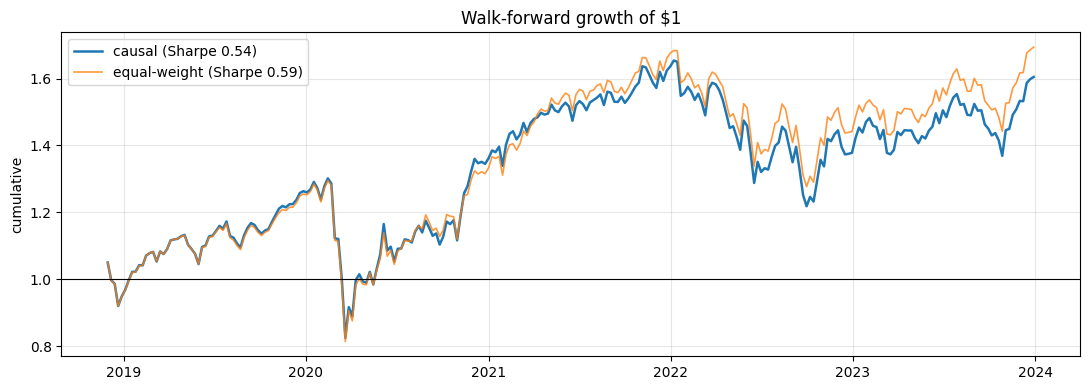

In [12]:
# Equity curves over the active backtest region.
d = BT["dates"][BT["active"]]
plt.figure(figsize=(11, 4))
plt.plot(d, np.cumprod(1 + BT["strat"][BT["active"]]), label=f"causal (Sharpe {s['sharpe']:.2f})", lw=1.8)
plt.plot(d, np.cumprod(1 + BT["bench"][BT["active"]]), label=f"equal-weight (Sharpe {b['sharpe']:.2f})", lw=1.2, alpha=.8)
plt.axhline(1, color="k", lw=.8); plt.legend(); plt.title("Walk-forward growth of $1")
plt.ylabel("cumulative"); plt.tight_layout(); plt.show()

---
## 9. Credibility checks — try to *kill* the signal <a name="credibility"></a>

A backtested Sharpe means nothing until it survives adversarial tests.

1. **Placebo (time permutation).** Shuffle the stock block's rows so any parent→stock
   *timing* is destroyed while marginals are untouched. A real signal should collapse
   toward the placebo's level; if causal ≈ placebo, **you have no edge.**
2. **Causal-vs-correlation ablation.** Rebuild the *same* pipeline but pick parents by
   **top lagged Pearson correlation** (no conditioning). If PCMCI doesn't beat it, the
   conditioning isn't earning its complexity.
3. **Cross-window edge stability.** Refit on disjoint halves; count persisting
   macro→stock edges. Transportable edges (§1) are the tradable ones.

> **Interpreting honestly.** On real US equities this naive signal typically shows
> **causal ≈ placebo ≈ 0** after costs — i.e. *no demonstrable alpha.* That is a
> legitimate, publishable-quality finding, not a failure of the notebook. The point of
> the harness is to reach that verdict *rigorously* instead of being fooled by an
> in-sample curve. Turn to §10 for honest levers that *might* change it.

In [ ]:
# 1) PLACEBO — permute the stock block in time; causal timing is destroyed.
rng = np.random.default_rng(123)
placebo = RETS.copy()
placebo.iloc[:, N_MACRO:] = placebo.iloc[:, N_MACRO:].values[rng.permutation(len(placebo))]
BT_PLACEBO = walk_forward(placebo, CFG, N_MACRO, verbose=False)
gap = BT["stats"]["sharpe"] - BT_PLACEBO["stats"]["sharpe"]
print(f"causal Sharpe {BT['stats']['sharpe']:+.2f}  vs  placebo {BT_PLACEBO['stats']['sharpe']:+.2f}"
      f"  ->  edge = {gap:+.2f} Sharpe")
print("A small/negative gap means the causal structure isn't adding tradable info.")

In [ ]:
# 2) CAUSAL vs CORRELATION ablation — same machinery, correlation-chosen parents.
def corr_parents(window_array, cfg, n_macro, top_k=3):
    """Each stock's top_k macro parents by |lagged Pearson corr| (no conditioning)."""
    x = preprocess(window_array, cfg); n_vars = x.shape[1]; edges = []
    for s in range(n_macro, n_vars):
        cand = []
        for m in range(n_macro):
            for tau in range(cfg.tau_min, cfg.tau_max + 1):
                a, bb = x[tau:, s], x[:-tau, m]
                if a.std() == 0 or bb.std() == 0:
                    continue
                c = float(np.corrcoef(a, bb)[0, 1])
                cand.append((abs(c), dict(src=m, tgt=s, lag=tau, mci=c, p=0.0)))
        for _, e in sorted(cand, key=lambda z: -z[0])[:top_k]:
            edges.append(e)
    return edges


def walk_forward_corr(rets_df, cfg, n_macro):
    arr = rets_df.values; T, n_vars = arr.shape; stock_idx = list(range(n_macro, n_vars))
    rebal_days = list(range(cfg.window, T - 1, cfg.rebal_every))
    if cfg.max_refits: rebal_days = rebal_days[:cfg.max_refits]
    strat = np.zeros(T); w_prev = np.zeros(len(stock_idx))
    for ri, r in enumerate(rebal_days):
        pbs = parents_by_stock(corr_parents(arr[r - cfg.window:r], cfg, n_macro), stock_idx)
        end = rebal_days[ri + 1] if ri + 1 < len(rebal_days) else min(r + cfg.rebal_every, T)
        for day in range(r, end):
            w = scores_to_weights(score_on_day(arr, day, pbs, cfg), cfg, stock_idx)
            strat[day] = float(np.dot(w, arr[day, stock_idx])) - cfg.cost_bps * 1e-4 * np.abs(w - w_prev).sum()
            w_prev = w
    active = slice(rebal_days[0], rebal_days[-1] + cfg.rebal_every)
    return perf_stats(strat[active], cfg.ppy)

CORR_STATS = walk_forward_corr(RETS, CFG, N_MACRO)
print(f"{'signal':<16}{'Sharpe':>8}{'AnnRet':>9}")
print(f"{'PCMCI (causal)':<16}{BT['stats']['sharpe']:>8.2f}{BT['stats']['ann_ret']:>8.1%}")
print(f"{'lagged-corr':<16}{CORR_STATS['sharpe']:>8.2f}{CORR_STATS['ann_ret']:>8.1%}")
print("\nIf PCMCI <= lagged-corr, conditioning isn't adding value at these settings.")

In [ ]:
# 3) CROSS-WINDOW EDGE STABILITY — do edges persist across disjoint periods?
half = RETS.shape[0] // 2
def macro_edge_set(window_array):
    val, p, acc = fit_pcmci(window_array, CFG, N_MACRO)
    return {(e["src"], e["tgt"], e["lag"])
            for e in extract_edges(val, p, acc, N_MACRO, N_VARS) if e["src"] < N_MACRO}
E1, E2 = macro_edge_set(RETS.values[:half]), macro_edge_set(RETS.values[half:])
inter, union = len(E1 & E2), len(E1 | E2)
print(f"1st half: {len(E1)} macro->stock edges | 2nd half: {len(E2)}")
print(f"Persisted in both: {inter}  |  Jaccard stability = {inter/union if union else 0:.2f} "
      f"(higher = more transportable / tradable)")

---
## 10. When the verdict is "no alpha" — honest levers to try next <a name="next"></a>

If §9 says causal ≈ placebo (the common real-data outcome), **do not** p-hack your way
to a pretty curve by toggling knobs until the backtest smiles — that just overfits the
one history you have (López de Prado, §11). The disciplined moves, each with a *reason*
to expect signal, not just a hope:

| Lever | Why it might genuinely help | How |
|---|---|---|
| **Sector/industry factors** as parents | single names respond to *sector* shocks more than broad macros | add sector ETFs (XLE, XLF, XLK…) to `MACRO_TICKERS` |
| **Trade only *stable* edges** | edges persisting across windows (§9) are the transportable ones | keep an edge only if it appeared in the last *k* refits |
| **Longer horizon** | weekly→monthly lead-lag is stronger and cheaper to trade | `frequency` + resample logic; raise `window` |
| **Ensemble the graph** | bootstrap windows, keep edges above a frequency threshold | wrap `fit_pcmci` in a bootstrap loop |
| **Contemporaneous structure** | some links are same-bar (use PCMCI+ with `tau_min=0`) | swap `run_pcmci` → `run_pcmciplus` |

Change **one lever at a time**, and judge it by the **§9 gap**, not the raw Sharpe.
The `run_experiment` helper prints exactly that:

In [ ]:
def run_experiment(**overrides):
    """Clone CFG with overrides, run the full stack, print causal vs placebo (the gap)."""
    cfg = replace(CFG, **overrides)
    rets, names, n_macro, truth = build_panel(cfg)
    bt = walk_forward(rets, cfg, n_macro, verbose=False)
    rng = np.random.default_rng(123); pl = rets.copy()
    pl.iloc[:, n_macro:] = pl.iloc[:, n_macro:].values[rng.permutation(len(pl))]
    plb = walk_forward(pl, cfg, n_macro, verbose=False)["stats"]["sharpe"]
    label = ", ".join(f"{k}={v}" for k, v in overrides.items()) or "baseline"
    print(f"[{label}]  causal={bt['stats']['sharpe']:+.2f}  placebo={plb:+.2f}  "
          f"edge={bt['stats']['sharpe']-plb:+.2f}  annRet={bt['stats']['ann_ret']:+.1%}")
    return bt

# Example — uncomment to compare a lever against baseline:
# run_experiment()                      # baseline
# run_experiment(fdr_scope="global")    # stricter multiple-testing
print("run_experiment(...) ready — judge levers by the 'edge' (causal - placebo), not raw Sharpe.")

---
## 11. References <a name="refs"></a>

**Causal discovery for trading / portfolios**
- Ong, R. & Herremans, D. (2024). *Trading with Time Series Causal Discovery: An
  Empirical Study.* arXiv:2408.15846.
- *Causal Discovery in Financial Markets: A Framework for Nonstationary Time-Series
  Data* (2023). arXiv:2312.17375 — CD-NOTS; ParCorr < ~200 obs, kernel tests above.
- *Is Causality Necessary for Efficient Portfolios?* (2025). arXiv:2507.23138.

**Method**
- Runge, J. et al. (2019). *Detecting and quantifying causal associations in large
  nonlinear time series datasets.* Science Advances 5(11). (PCMCI)
- Runge, J. (2020). *Discovering contemporaneous and lagged causal relations…* UAI. (PCMCI+)
- Spirtes, Glymour & Scheines (2000). *Causation, Prediction, and Search.* (PC algorithm)
- tigramite: https://github.com/jakobrunge/tigramite

**Foundations (why causality, not correlation)**
- Reichenbach (1956). *The Direction of Time.* (Common Cause Principle)
- Pearl (2009). *Causality*; Bareinboim et al. (2022). *On Pearl's Hierarchy…* (Causal Hierarchy Theorem)
- Granger & Newbold (1974). *Spurious regressions in econometrics.*
- Peters, Bühlmann & Meinshausen (2016). *Causal inference using invariant prediction.* JRSS-B.
- Sugihara et al. (2012). *Detecting causality in complex ecosystems.* Science. (mirage correlations)
- López de Prado (2018). *Advances in Financial Machine Learning.* (backtest overfitting)